# Description

Prove that the Noise Reduction model works on a 2D polinomial.

Add libs folder path to system variables in order to make the importation of local libraries easier.

In [40]:
import os
import sys


CURRENT_DIR = os.getcwd()
FOLDERS = CURRENT_DIR.split(os.sep)
TESIS_FOLDER_INDEX = FOLDERS.index('S-noise-gradient')
CURRENT_DIR = os.sep.join(FOLDERS[:TESIS_FOLDER_INDEX+1])
LIBS_PATH = os.path.join(CURRENT_DIR, 'src', 'libs')
assert os.path.exists(LIBS_PATH)
sys.path.append(LIBS_PATH)

Import external and local libraries

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import display
from tqdm import tqdm
import math
from typing import List

# Locals
from utils import *
from dataset import TensorDataset
from models import *
import config as cfg
from dlnr import DLNoiseReduction

Global / Path variables

In [42]:
DATA_PATH = os.path.join(CURRENT_DIR, 'data')
CHECKPOINT_PATH = os.path.join(CURRENT_DIR, 'checkpoints')
CONFIG_PATH = os.path.join(CURRENT_DIR, 'config')

Make sure that the GPU is being used

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert device.type == "cuda"

Functions definition

In [44]:
def polinomial_function(x:float):
    """
    Function that takes in a value x and returns its polinomial value.

    Args:
        x (float): value to be transformed.

    Returns:
        float: result of the polinomial function.
    """

    return x**4 -x**3 -20*(x**2) -20*x +6


def add_gaussian_noise(df:pd.DataFrame, columns:List[str], mean:float = 0.0, std:float = 0.1):
    """
    Adds Gaussian noise to specified columns in a DataFrame.

    Args:
        df (pandas.DataFrame): The DataFrame to which noise will be added.
        columns (list): A list of column names in the DataFrame to which noise will be added.
        mean (int, optional): The mean of the Gaussian distribution. Defaults to 0.
        std (float, optional): The standard deviation of the Gaussian distribution. Defaults to 0.1.

    Returns:
        pandas.DataFrame: The DataFrame with added Gaussian noise to specified columns.
    """
    for col in columns:
        df[col] = df[col] + np.random.normal(loc=mean, scale=std, size=len(df))
    return df

Generate 2D data with normal distribution at the points indicated in ‘means’ variable.  
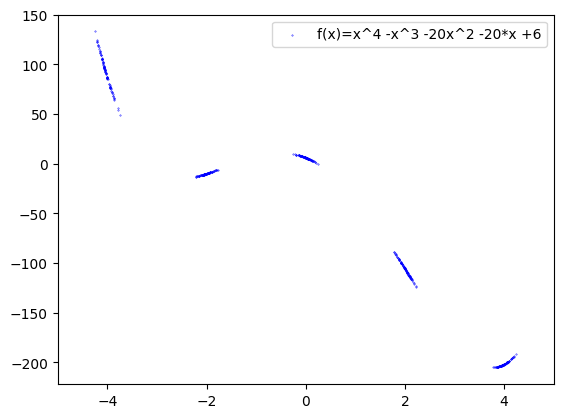

In [45]:
# means = [-4, -2, 0, 2, 4]
# X_train = [np.random.normal(loc=m, scale=0.1, size=(100)) for m in means]
# X_train = np.concatenate(X_train, axis=0)
# y_train = polinomial_function(X_train)

# df_train = pd.DataFrame({'X': X_train, 'y': y_train})

Generate continious 2D data like so  
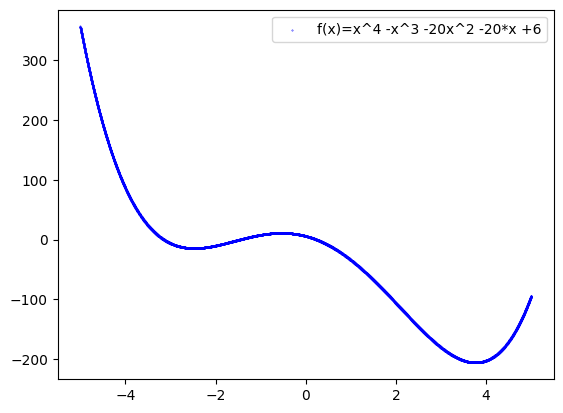

In [46]:
X = np.linspace(-5, 5, 10001)
y = polinomial_function(X)

df_data = pd.DataFrame({'X': X, 'y': y})
scaler = MinMaxScaler()
df_data = pd.DataFrame(scaler.fit_transform(df_data), columns=['X', 'y'])

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    df_data['X'].values, df_data['y'].values, test_size=0.2, random_state=42
)

# No noise XAI Benchmarck

In [48]:
model_params = {
    'ridge': {"alpha": 1.0},
    'pls': {"n_components": 1},
    'tree': {"max_depth": 5},
    'svm': {"dual": 'auto'},
    'knn': {"n_neighbors": 5, "weights": 'uniform', "algorithm": 'auto', "leaf_size": 30, "p": 2, "n_jobs": None},
}
xai_benchmark = XAI_benchmark(is_ts = False, model_params = model_params)

In [49]:
xai_benchmark.fit(X_train.reshape(-1,1), y_train)

Fitting Ridge model...
Fitting Partial Least Squares model...
Fitting Decision Tree model...
Fitting Support Vector Machine model...
Fitting K-Nearest Neighbours model...
All models fitted!


In [50]:
xai_benchmark.predict(X_test.reshape(-1,1), y_test, get_metrics=True)

({'ridge': array([0.22483002, 0.32187484, 0.50463845, ..., 0.54400102, 0.18292993,
         0.03897186]),
  'pls': array([0.22471499, 0.32190525, 0.50494276, ..., 0.54436432, 0.18275211,
         0.0385783 ]),
  'decision_tree': array([0.27474837, 0.36268029, 0.36268029, ..., 0.50534442, 0.17933686,
         0.01692155]),
  'svm': array([0.2178222 , 0.31050188, 0.48504468, ..., 0.52263669, 0.1778068 ,
         0.04032405]),
  'knn': array([0.27668958, 0.38415741, 0.37786457, ..., 0.49270819, 0.18683249,
         0.02642518])},
 {'ridge': {'mse': 0.009051272491944037,
   'rmse': 0.09513817578629535,
   'mae': 0.07506427492265716,
   'R2': 0.7892970227350826},
  'pls': {'mse': 0.00904823574080855,
   'rmse': 0.09512221475979493,
   'mae': 0.0750639317131035,
   'R2': 0.7893677147296092},
  'decision_tree': {'mse': 0.00019912178713996705,
   'rmse': 0.01411105195015478,
   'mae': 0.011919608469017939,
   'R2': 0.9953646790077258},
  'svm': {'mse': 0.00930618514400554,
   'rmse': 0.0964685

Add goussian noise to the dataframe

In [51]:
sigma = 0.05
df_noisy = add_gaussian_noise(
    df=df_data.copy(),
    columns=[x for x in df_data.columns],
    mean=0.0,
    std=sigma
)

Plot the new noisy data

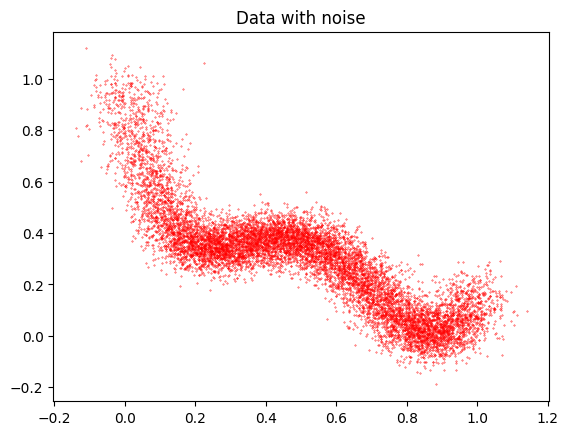

In [52]:
plt.title('Data with noise')
plt.scatter(df_noisy['X'], df_noisy['y'], color='r', s=0.1)

In [53]:
X_train_noisy, X_test_noisy, y_train_noisy, y_test_noisy = train_test_split(
    df_noisy['X'].values, df_noisy['y'].values, test_size=0.2, random_state=42
)

# Noisy XAI Benchmarck

In [54]:
xai_benchmark.fit(X_train_noisy.reshape(-1,1), y_train_noisy)

Fitting Ridge model...
Fitting Partial Least Squares model...
Fitting Decision Tree model...
Fitting Support Vector Machine model...
Fitting K-Nearest Neighbours model...
All models fitted!


In [55]:
xai_benchmark.predict(X_test_noisy.reshape(-1,1), y_test, get_metrics=True)

({'ridge': array([0.26207111, 0.32678033, 0.50000494, ..., 0.5402193 , 0.19396552,
         0.07421878]),
  'pls': array([0.26201455, 0.32681863, 0.50029717, ..., 0.54057048, 0.19380913,
         0.07388684]),
  'decision_tree': array([0.34675816, 0.36468826, 0.40899498, ..., 0.55082605, 0.2206625 ,
         0.03062554]),
  'svm': array([0.25543559, 0.3164591 , 0.47981717, ..., 0.51774099, 0.19120917,
         0.07828297]),
  'knn': array([0.36507495, 0.34364814, 0.31663891, ..., 0.66623527, 0.174835  ,
         0.00526624])},
 {'ridge': {'mse': 0.010201023751313454,
   'rmse': 0.10100011758069123,
   'mae': 0.07858979973644091,
   'R2': 0.7625321657849862},
  'pls': {'mse': 0.010198873770058788,
   'rmse': 0.10098947356065774,
   'mae': 0.07859602174008401,
   'R2': 0.7625822148197297},
  'decision_tree': {'mse': 0.005404607851924665,
   'rmse': 0.07351603805921987,
   'mae': 0.04680142549697525,
   'R2': 0.8741870862507541},
  'svm': {'mse': 0.01048080931478657,
   'rmse': 0.10237582

Create Datasets for DataLoaders

In [66]:
# Transform the data into a tensor
train_dataset = TensorDataset(
    x=X_train_noisy.reshape(-1,1),
    y=y_train_noisy.reshape(-1,1)
)
# Transform the data into a tensor
val_dataset = TensorDataset(
    x=X_test_noisy.reshape(-1,1),
    y=y_test_noisy.reshape(-1,1)
)

# Create the dataloaders
batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

Create Neural Network model

In [69]:
model = GridFullyDenseNN(
    n_layers=2,
    hidden_layers=[
        (1, 1024),
        (1024, 1),
    ],
    dropout_layers=[
        0.0,
        0.0,
    ],
    activation_func_layers=[
        nn.ReLU(),
        nn.Identity(),
    ],
    want_dropout=[
        False,
        False,
    ],
    want_linear=[
        True,
        True,
    ],
    want_activation=[
        True,
        False,
    ],
)
model.to(device)

GridFullyDenseNN(
  (model): Sequential(
    (linear_0): Linear(in_features=1, out_features=1024, bias=True)
    (activation_0): ReLU()
    (linear_1): Linear(in_features=1024, out_features=1, bias=True)
  )
)

Set model parameters and create the model Trainer object

In [70]:
lr = 0.001
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# Define the trainer
trainer_basic = Trainer(
    model=model,
    train_generator=train_dataloader,
    val_generator=val_dataloader,
    device=device,
    criterion=criterion,
    optimizer=optimizer,
    epoch_scheduler=None,
    batch_scheduler=None,
    patience=15,
    epochs=500,
    checkpoints_path=os.path.join(CHECKPOINT_PATH, f'model_noise_{sigma}_polinomial')
)

Train the model

In [71]:
model, train_losses, val_losses, best_train_loss, best_val_loss = trainer_basic.fit(verbose=True)

Training is started!


Epochs loop:   0%|                                         | 0/500 [00:00<?, ?epoch/s]


Epochs loop:   7%| | 33/500 [00:44<10:36,  1.36s/epoch, Train loss: 0.0075782800689339

Training stopped as validation loss did not improve for 15 epochs.


or load a checkpoint

In [ ]:
# model.load_state_dict(torch.load(os.path.join(CHECKPOINT_PATH, f'model_noise_{sigma}_polinomial.pth')))

Predict over the datasets

In [72]:
y_pred_test = model(torch.tensor(X_test_noisy.reshape(-1, 1)).float().to(device)).cpu().detach().numpy().reshape(-1)

Show the metrics

In [73]:
gt_values = y_test_noisy
predicted_values = y_pred_test

In [74]:
mae = mean_absolute_error(gt_values, predicted_values)
mse = mean_squared_error(gt_values, predicted_values)
rmse = np.sqrt(mse)
mape = np.mean(np.abs(gt_values - predicted_values) / gt_values) * 100
r_squared = r2_score(gt_values, predicted_values)
print("MAE: ", mae)
print("MAPE: ", mape)
print("MSE: ", mse)
print("RMSE: ", rmse)
print("R-squared: ", r_squared)

MAE:  0.0640070125986267
MAPE:  20.924960996798493
MSE:  0.007672856498445829
RMSE:  0.08759484287585559
R-squared:  0.8307163941044791


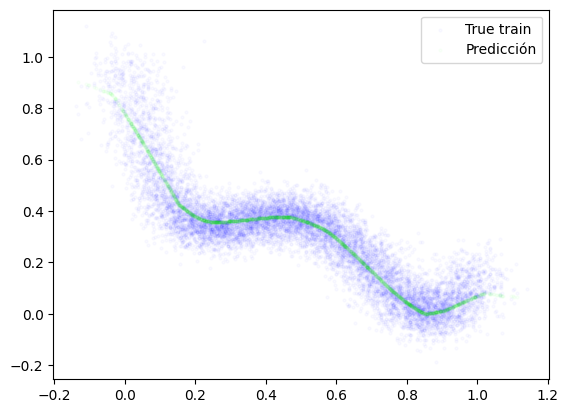

In [75]:
plt.scatter(df_noisy['X'].values, df_noisy['y'].values, color='b', label='True train', s=5, alpha=0.02)
plt.scatter(X_test_noisy, y_pred_test, color='lime', label='Predicción', s=5, alpha=0.02)
plt.legend()
plt.show()

# Gradients to reduce noise

In [76]:
df_no_noise = df_noisy.copy()
dlnr = DLNoiseReduction(model=model, criterion=criterion)
dlnr.fit(df_noisy['X'].values.reshape(-1, 1), df_noisy['y'].values.reshape(-1, 1))

In [78]:
df_no_noise['X'], df_no_noise['y'] = dlnr.transform(
                                                nrr=0.05,
                                                nr_threshold=0.01,
                                                max_epochs=200,
                                                plot_progress=False,
                                                path_to_save_imgs=None
)

# Denoised XAI Benchmark

In [80]:
xai_benchmark.fit(df_no_noise['X'].values.reshape(-1,1), df_no_noise['y'].values)

Fitting Ridge model...
Fitting Partial Least Squares model...
Fitting Decision Tree model...
Fitting Support Vector Machine model...
Fitting K-Nearest Neighbours model...
All models fitted!


In [81]:
xai_benchmark.predict(df_no_noise['X'].values.reshape(-1,1), df_no_noise['y'].values.reshape(-1,1), get_metrics=True)

({'ridge': array([ 0.67665659,  0.64478139,  0.67672201, ..., -0.03321105,
         -0.03320896, -0.03320576]),
  'pls': array([ 0.6770939 ,  0.64518186,  0.6771594 , ..., -0.03359438,
         -0.03359228, -0.03358908]),
  'decision_tree': array([0.88136133, 0.88136133, 0.88136133, ..., 0.08097317, 0.08097317,
         0.08097317]),
  'svm': array([ 0.65499693,  0.62444805,  0.65505963, ..., -0.0253333 ,
         -0.02533129, -0.02532823]),
  'knn': array([0.89703271, 0.87188594, 0.89703271, ..., 0.08994317, 0.08987279,
         0.08992574])},
 {'ridge': {'mse': 0.006049731492405585,
   'rmse': 0.07778001987917968,
   'mae': 0.06456356998531873,
   'R2': 0.8513294160198392},
  'pls': {'mse': 0.0060496853013764255,
   'rmse': 0.07777972294484228,
   'mae': 0.06457099851704982,
   'R2': 0.851330551152413},
  'decision_tree': {'mse': 0.00019452542946548704,
   'rmse': 0.013947237341691976,
   'mae': 0.011434047992969222,
   'R2': 0.9952195879711472},
  'svm': {'mse': 0.006147935771668926

In [82]:
xai_benchmark.predict(df_data['X'].values.reshape(-1,1), df_data['y'].values, get_metrics=True)

({'ridge': array([ 0.6141393 ,  0.61407609,  0.61401287, ..., -0.01787322,
         -0.01793644, -0.01799965]),
  'pls': array([ 0.61450434,  0.61444106,  0.61437777, ..., -0.01823882,
         -0.01830211, -0.01836539]),
  'decision_tree': array([0.79860287, 0.79860287, 0.79860287, ..., 0.08097317, 0.08097317,
         0.08097317]),
  'svm': array([ 0.59508097,  0.59502039,  0.5949598 , ..., -0.01063367,
         -0.01069425, -0.01075484]),
  'knn': array([0.78394361, 0.78341469, 0.77910383, ..., 0.07392607, 0.07392607,
         0.07529002])},
 {'ridge': {'mse': 0.00872420913347029,
   'rmse': 0.09340347495393461,
   'mae': 0.07381237100869156,
   'R2': 0.7878464334078996},
  'pls': {'mse': 0.008725287598414408,
   'rmse': 0.09340924792767795,
   'mae': 0.07382428097311153,
   'R2': 0.7878202075138571},
  'decision_tree': {'mse': 0.00137989261621896,
   'rmse': 0.03714690587678818,
   'mae': 0.022425482408512644,
   'R2': 0.9664440483296268},
  'svm': {'mse': 0.008828060506618543,
   

In [83]:
xai_benchmark.predict(X_test_noisy.reshape(-1,1), y_test_noisy, get_metrics=True)

({'ridge': array([0.25698327, 0.32504961, 0.50726112, ..., 0.54956181, 0.18534437,
         0.05938515]),
  'pls': array([0.25693542, 0.32508045, 0.50750261, ..., 0.54985219, 0.1852137 ,
         0.05910887]),
  'decision_tree': array([0.36335645, 0.36335645, 0.39789376, ..., 0.52962276, 0.19272307,
         0.01312324]),
  'svm': array([0.25278611, 0.31802023, 0.49264997, ..., 0.53319053, 0.18412808,
         0.06341   ]),
  'knn': array([3.35121072e-01, 3.86768987e-01, 4.01602469e-01, ...,
         5.38704926e-01, 2.00036022e-01, 2.50196831e-04])},
 {'ridge': {'mse': 0.01278303586884054,
   'rmse': 0.11306208855686568,
   'mae': 0.08944335574781509,
   'R2': 0.7179722562767294},
  'pls': {'mse': 0.012785422844476601,
   'rmse': 0.11307264410314548,
   'mae': 0.08946456405606608,
   'R2': 0.7179195932505229},
  'decision_tree': {'mse': 0.007769286569338919,
   'rmse': 0.08814355659569745,
   'mae': 0.06440793239747566,
   'R2': 0.8285888904660558},
  'svm': {'mse': 0.012809083929976,
